# Assignment 2


# Problem 1
Data Generation

In [1]:
import numpy as np
from scipy.stats import multivariate_normal

# Define the parameters and distributions
m01 = np.array([-0.9, -1.1])
m02 = np.array([0.8, 0.75])
m11 = np.array([-1.1, 0.9])
m12 = np.array([0.9, -0.75])
cov = np.array([[0.75, 0], 
                [0, 1.25]])
w = 0.5
p_L0, p_L1 = 0.6, 0.4

def p_xL0(x):
    return w*multivariate_normal.pdf(x, mean=m01, cov=cov)+w*multivariate_normal.pdf(x, mean=m02, cov=cov)

def p_xL1(x):
    return w*multivariate_normal.pdf(x, mean=m11, cov=cov)+w*multivariate_normal.pdf(x, mean=m12, cov=cov)

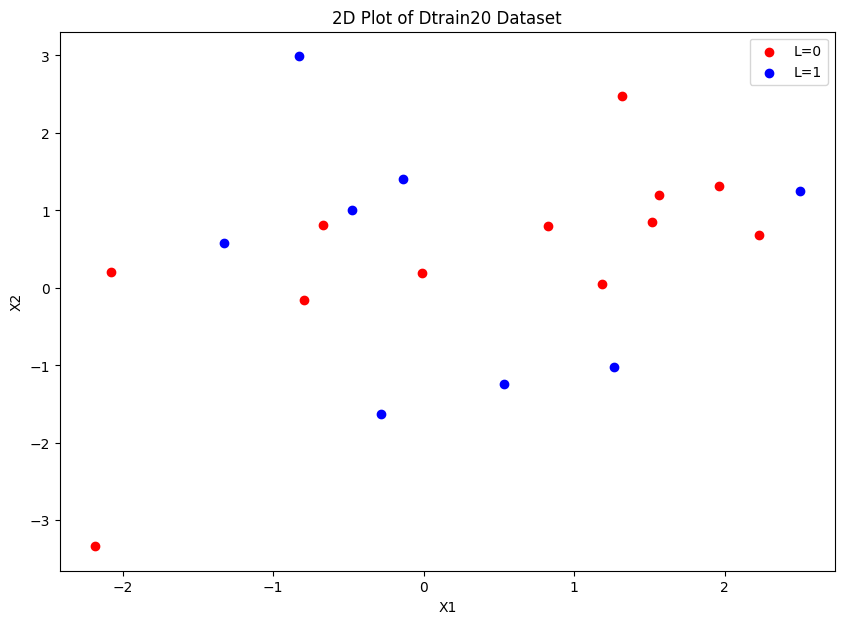

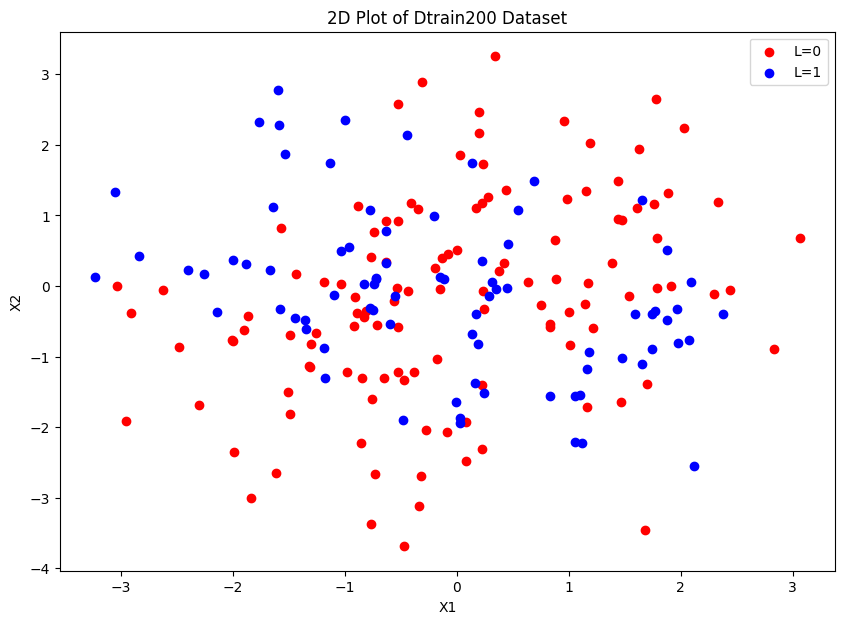

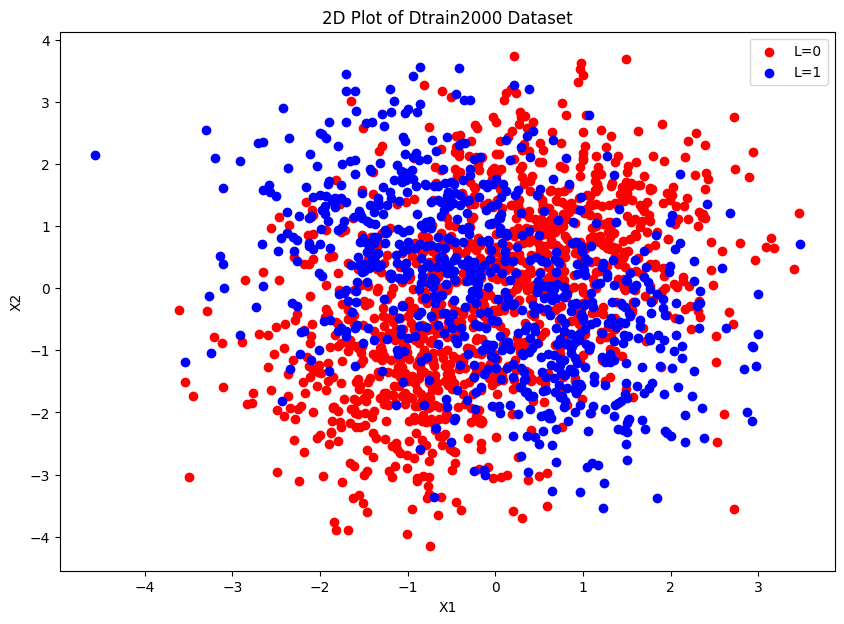

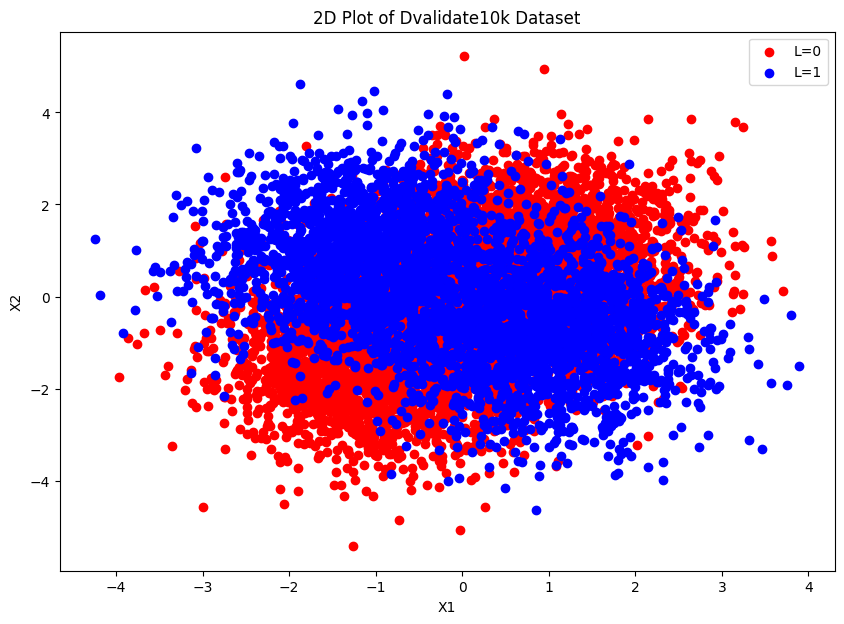

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Generate samples by choosing class L based on the priors
'''
for n in [20, 200, 2000, 10000]:
    X = []
    y = []
    X_g1l0 = np.random.multivariate_normal(mean=m01, cov=cov, size=int(0.5*p_L0*n))
    X_g2l0 = np.random.multivariate_normal(mean=m02, cov=cov, size=int(0.5*p_L0*n))
    X.append(np.vstack([X_g1l0, X_g2l0]))
    y += [0] * len(np.vstack([X_g1l0, X_g2l0]))

    X_g1l1 = np.random.multivariate_normal(mean=m11, cov=cov, size=int(0.5*p_L1*n))
    X_g2l1 = np.random.multivariate_normal(mean=m12, cov=cov, size=int(0.5*p_L1*n))
    X.append(np.vstack([X_g1l1, X_g2l1]))
    y += [1] * len(np.vstack([X_g1l1, X_g2l1]))

    # combine all the variables in one matrix
    X = np.vstack(X)
    y = np.array(y)
    # store the generated dataset in a dataframe
    data = pd.DataFrame(X, columns = ['X1', 'X2'])
    data['L'] = y
    data.to_csv(f'samples{n}.csv', index=False)
'''
d20 = pd.read_csv('samples20.csv')
d20.columns.name = 'Dtrain20'
d200 = pd.read_csv('samples200.csv')
d200.columns.name = 'Dtrain200'
d2000 = pd.read_csv('samples2000.csv')
d2000.columns.name = 'Dtrain2000'
d10k = pd.read_csv('samples10000.csv')
d10k.columns.name = 'Dvalidate10k'

# display the generated data in a 2d map
def plotdata(data):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111)

    # Scatter plot, color by y values (classes)
    idx = np.where((data.L == 0))[0]
    scatter = ax.scatter(data.X1[idx], data.X2[idx], c='r', marker='o', label = 'L=0')

    idx = np.where((data.L == 1))[0]
    scatter = ax.scatter(data.X1[idx], data.X2[idx], c='b', marker='o', label = 'L=1')


    # Add labels and title
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_title(f'2D Plot of {data.columns.name} Dataset')
    plt.legend()
    plt.show()

for d in [d20, d200, d2000, d10k]:
    plotdata(d)

Part 1

In [3]:
X = np.array(d2000[['X1', 'X2']])
L = np.array(d2000.L)

def likelihood_ratio(x):
    return p_xL1(x)/p_xL0(x)
def classifier(X, gamma=1.5):
    return np.array([1 if likelihood_ratio(x) > gamma else 0 for x in X])
'''
gamma_vals = np.linspace(0, 10, 600)

tpr = []
fpr = []
for gamma in lam_vals:

    L_pred = classifier(X, gamma=gamma)
    tp = len(L[(L==1) & (L_pred==1)])
    fp = len(L[(L==0) & (L_pred==1)])
    tn = len(L[(L==0) & (L_pred==0)])
    fn = len(L[(L==1) & (L_pred==0)])

    tpr.append(tp/(tp+fn))
    fpr.append(fp/(fp+tn))

roc_values = pd.DataFrame({'Gamma': lam_vals, 'False Alarm': fpr, 'Detection': tpr})
roc_values.to_csv('D10k_ROC.csv', index=False)
'''

"\ngamma_vals = np.linspace(0, 10, 600)\n\ntpr = []\nfpr = []\nfor gamma in lam_vals:\n\n    L_pred = classifier(X, gamma=gamma)\n    tp = len(L[(L==1) & (L_pred==1)])\n    fp = len(L[(L==0) & (L_pred==1)])\n    tn = len(L[(L==0) & (L_pred==0)])\n    fn = len(L[(L==1) & (L_pred==0)])\n\n    tpr.append(tp/(tp+fn))\n    fpr.append(fp/(fp+tn))\n\nroc_values = pd.DataFrame({'Gamma': lam_vals, 'False Alarm': fpr, 'Detection': tpr})\nroc_values.to_csv('D10k_ROC.csv', index=False)\n"

The optimum threshold is 1.552587646076795
the minimum achieveable error is 0.269


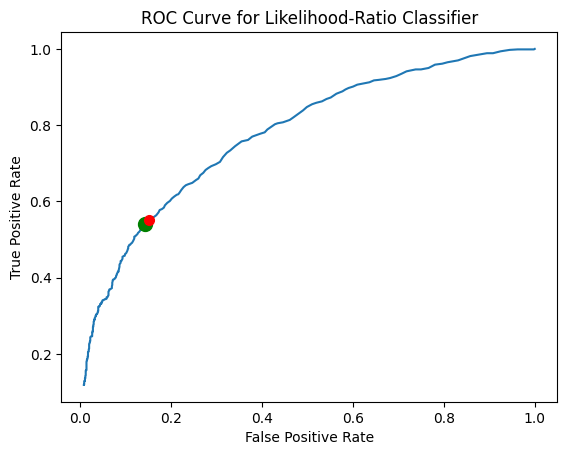

In [4]:
roc_values = pd.read_csv('GammaValues.csv')

import matplotlib.pyplot as plt

# create a column including the error term for each gamma value
roc_values['error'] = roc_values['False Alarm']*p_L0 + (1 - roc_values['Detection'])*p_L1
# find the index of the row with minimum error
opt_index = roc_values.error.idxmin()
# what is the corresponding optimal gamma value for minimum error?
opt_gamma = roc_values['Gamma'][opt_index]
print(f'The optimum threshold is {opt_gamma}')
print(f'the minimum achieveable error is {roc_values.error[opt_index]}')

# plot the probability of detection wrt false alarm
plt.plot(roc_values['False Alarm'], roc_values['Detection'])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# specify the optimum value on the graph
plt.plot(roc_values['False Alarm'][opt_index], roc_values['Detection'][opt_index], marker = 'o', markersize=10, markeredgecolor="green", markerfacecolor="green")
plt.plot(roc_values['False Alarm'][90], roc_values['Detection'][90], marker = 'o', markersize=7, markeredgecolor="red", markerfacecolor="red")
plt.title("ROC Curve for Likelihood-Ratio Classifier")
plt.show()

c:\Users\tabat\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


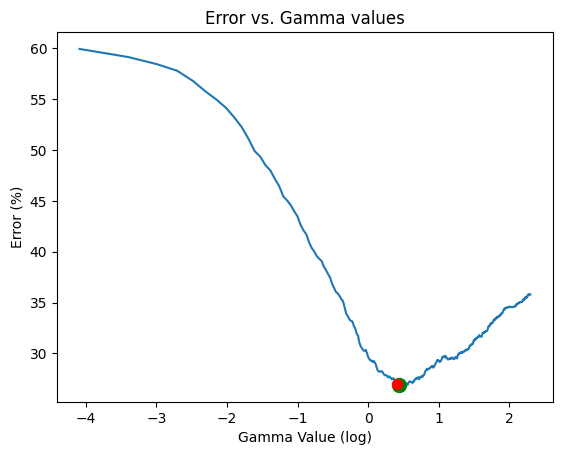

0.26999999999999996


In [5]:
plt.plot(np.log(roc_values['Gamma']), roc_values['error']*100)
plt.xlabel("Gamma Value (log)")
plt.ylabel("Error (%)")
# specify the optimum value on the graph
plt.plot(np.log(roc_values['Gamma'][opt_index]), roc_values['error'][opt_index]*100, marker = 'o', markersize=10, markeredgecolor="green", markerfacecolor="green")
plt.plot(np.log(roc_values['Gamma'][90]), roc_values['error'][90]*100, marker = 'o', markersize=7, markeredgecolor="red", markerfacecolor="red")
plt.title("Error vs. Gamma values")
plt.show()
print(roc_values['error'][90])

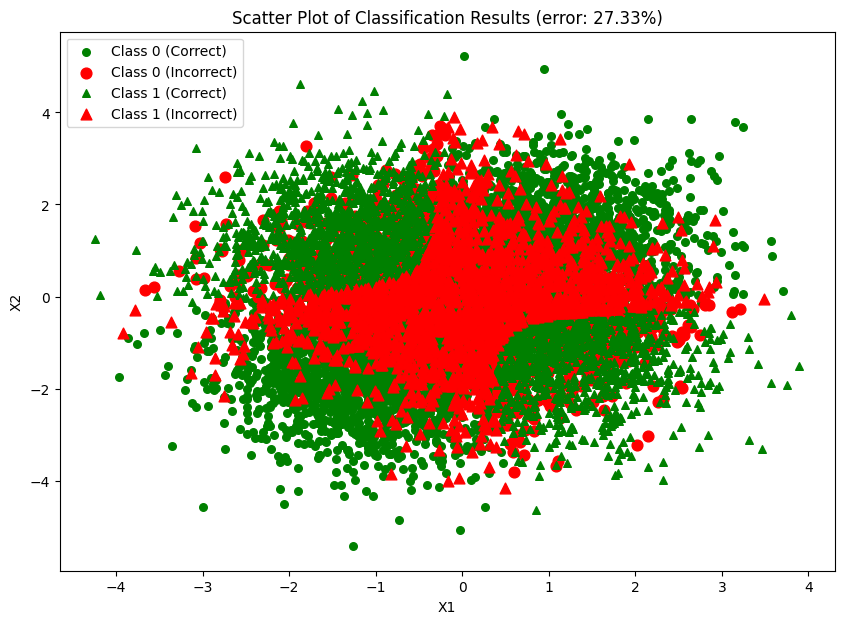

In [6]:
def plot_classification(X, L, L_pred):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111)
    
    # Define markers for each class (0: circle, 1: triangle)
    markers = {0: 'o', 1: '^'}
    
    # Iterate through each class and plot correctly/incorrectly classified points
    for label in range(2):
        # plt the detected points with green
        correct_idx = np.where((L == label) & (L_pred == label))[0]
        ax.scatter(X[correct_idx, 0], X[correct_idx, 1],
                   c='g', marker=markers[label], label=f'Class {label} (Correct)', s=30)
        
        # plot the false positive and false negative with red
        incorrect_idx = np.where((L == label) & (L_pred != label))[0]
        ax.scatter(X[incorrect_idx, 0], X[incorrect_idx, 1],
                   c='red', marker=markers[label], label=f'Class {label} (Incorrect)', s=60)

    # Adding labels and title
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    plt.title(f'Scatter Plot of Classification Results (error: {np.mean(L!=L_pred)*100}%)')
    plt.legend()
    plt.show()

X = np.array(d10k[['X1', 'X2']])
L = np.array(d10k.L)
L_pred = classifier(X, gamma=opt_gamma)
plot_classification(X, L, L_pred)


Part 2
(a)

In [7]:
# Define functions to minimize the cost

def sigmoid(z):
    return  1 / (1 + np.exp(-z))

def calculate_weights(X, y):
    # Apply the closed-form solution for weights
    return np.linalg.inv(X.T @ X) @ X.T @ y


def cost(theta, X, y):
    N = len(y)
    theta = theta.reshape(-1, 1) 
    h_theta = sigmoid(np.dot(X, theta))
    co = (-1 / N)*np.sum((y*np.log(h_theta)) + ((1 - y)*np.log(1 - h_theta)))
    return co

def gradient_descent(X, y, learning_rate=0.01, iterations=10000):
    N, m = X.shape
    theta = np.ones(m)
    for i in range(iterations):
        y_pred = sigmoid(np.dot(X, theta))
        theta = theta + learning_rate*(np.dot((y[0]-y_pred), X)/N)
    
    return theta

In [8]:
from scipy.optimize import minimize
theta_optimized = []
for data in [d20, d200, d2000]:
    X = np.array(data[['X1', 'X2']])
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    y = np.array(data[['L']])
    N, i = X.shape
    theta = np.ones(i)
    theta = minimize(fun=cost, x0=theta, args=(X, y))
    theta_optimized.append(theta.x)
    print(f'Optimized theta values using train set {data.columns.name}:', theta.x)

Optimized theta values using train set Dtrain20: [-0.38244153 -0.15292959  0.04723809]
Optimized theta values using train set Dtrain200: [-0.40225873 -0.06423515  0.06461542]
Optimized theta values using train set Dtrain2000: [-0.40248803 -0.02118584  0.10748168]


In [9]:
def predict(X, theta):
    return sigmoid(np.dot(X, theta)) >= 0.5  # Return 1 if probability >= 0.5, else 0

X = np.array(d10k[['X1', 'X2']])
X = np.hstack([np.ones((X.shape[0], 1)), X])
y = np.array(d10k[['L']])
def p_error(theta, X, y): # compute probability of error of the model
    return(np.mean(y != predict(X, theta)))
for theta in theta_optimized:
    print(p_error(theta, X, y))

0.40618
0.40004
0.40042


Evaluating classifier trained on D_train [-0.38244153 -0.15292959  0.04723809]:


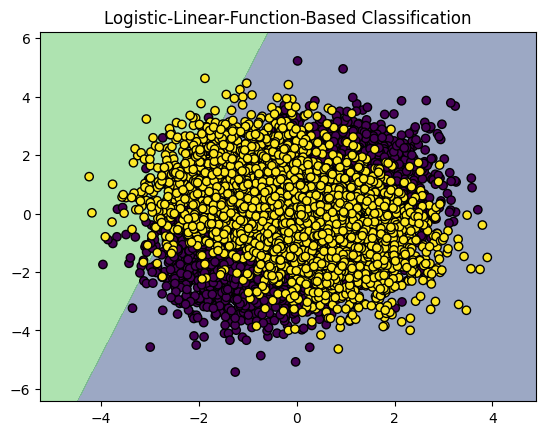

Evaluating classifier trained on D_train [-0.40225873 -0.06423515  0.06461542]:


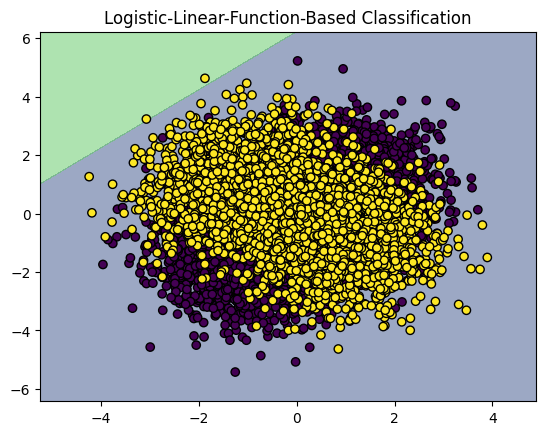

Evaluating classifier trained on D_train [-0.40248803 -0.02118584  0.10748168]:


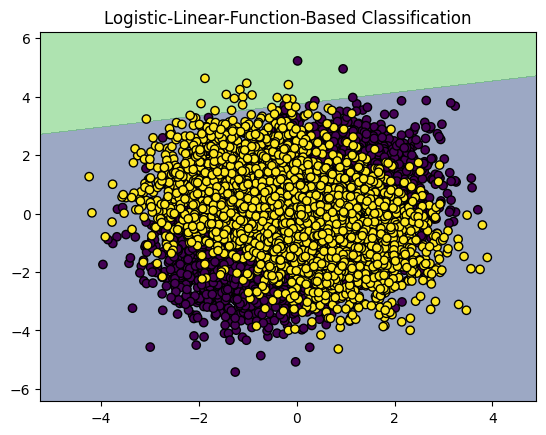

In [10]:
def plot_decision_boundary(w, X, y):
    x_min, x_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    y_min, y_max = X[:, 2].min() - 1, X[:, 2].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = sigmoid(np.dot(np.c_[np.ones((xx.size, 1)), xx.ravel(), yy.ravel()], w))
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.5)
    plt.scatter(X[:, 1], X[:, 2], c=y, edgecolors='k', marker='o')
    plt.title("Logistic-Linear-Function-Based Classification")
    plt.show()
X = np.array(d10k[['X1', 'X2']])
X = np.hstack([np.ones((X.shape[0], 1)), X])
y = np.array(d10k[['L']])
for w in theta_optimized:
    print(f'Evaluating classifier trained on D_train {w}:')
    # accuracy = evaluate_classifier(w, X_val, y_val)
    plot_decision_boundary(w, X, y)

Quadratic Function

In [11]:
def quadratic(X):
    X = np.hstack((X, np.array([X[:, 1]*X[:, 0]]).T))
    X = np.hstack((X, np.array([X[:, 0]**2]).T))
    X = np.hstack((X, np.array([X[:, 1]**2]).T))
    return X
theta_optimized = []
for data in [d20, d200, d2000]:
    X = np.array(data[['X1', 'X2']])
    y = np.array(data[['L']])
    X = quadratic(X)
    X = np.hstack([np.ones((len(y), 1)), X])
    N, i = X.shape
    theta = np.ones(i)
    theta = minimize(fun=cost, x0=theta, args=(X, y))
    theta_optimized.append(theta.x)
    print(f'Optimized theta values using train set {data.columns.name}:', theta.x)

X = quadratic(np.array(d10k[['X1', 'X2']]))
y = np.array(d10k[['L']])
X = np.hstack([np.ones((len(y), 1)), X])


Optimized theta values using train set Dtrain20: [-2.87921332  1.31794588 -0.46900267 -3.49309567  0.93957311  1.90866209]
Optimized theta values using train set Dtrain200: [-0.05813109 -0.19181306 -0.01235893 -0.85307851 -0.02439901 -0.27616724]
Optimized theta values using train set Dtrain2000: [-0.35138394 -0.03666462 -0.0093041  -0.76514286  0.04601057 -0.06475081]


Classification Error: 34.96%


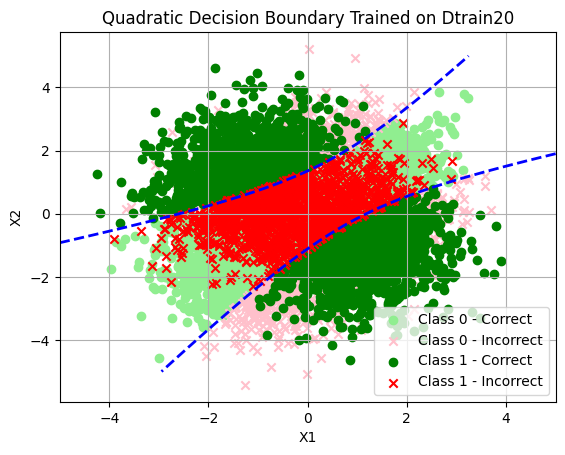

Classification Error: 28.05%


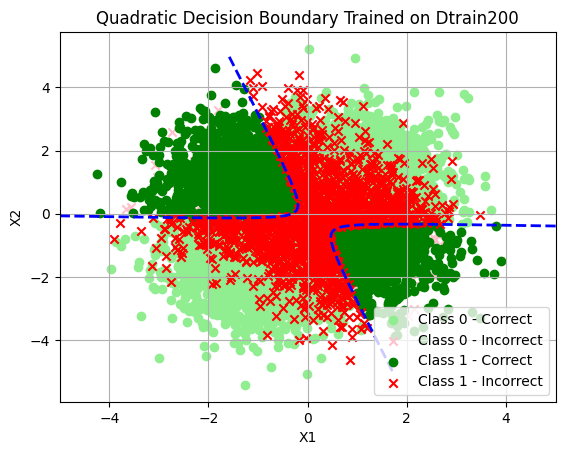

Classification Error: 27.34%


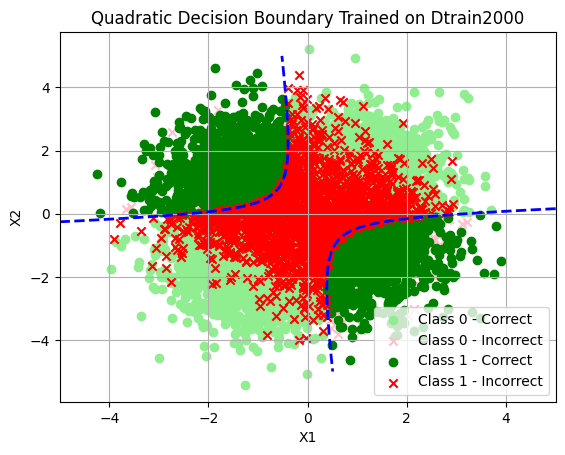

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_quad(x, y, theta, trainset):
    # Create a mesh grid for plotting
    x_min, x_max = -5, 5
    y_min, y_max = -5, 5
    x_vals = np.linspace(x_min, x_max, 400)
    y_vals = np.linspace(y_min, y_max, 400)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    # Compute Z based on the quadratic equation
    var = np.array([np.ones_like(X), X, Y, X * Y, X ** 2, Y ** 2])
    Z = np.tensordot(theta, var, axes=1)

    # Plot the boundary where Z = 0
    plt.contour(X, Y, Z, levels=[0], colors='blue', linewidths=2, linestyles='dashed')

    # Calculate decision boundary values for each point in data
    var_points = np.array([np.ones(x.shape[0]), x[:, 0], x[:, 1], x[:, 0] * x[:, 1], x[:, 0] ** 2, x[:, 1] ** 2]).T
    raw_predictions = np.dot(var_points, theta)

    # Convert raw predictions to class labels (assuming 0 and 1 in y)
    predictions = (raw_predictions > 0).astype(int)  # Threshold at 0 for binary classification

    # Calculate accuracy
    accuracy = np.mean(predictions == y) * 100
    print(f'Classification Error: {(100-accuracy):.2f}%')

    # Plot correctly and incorrectly classified points with different colors and shapes
    for label in np.unique(y):
        # Correctly classified points
        correct = (predictions == y) & (y == label)
        plt.scatter(x[correct, 0], x[correct, 1],
                    color='green' if label == 1 else 'lightgreen', 
                    marker='o', 
                    label=f'Class {label} - Correct')

        # Misclassified points
        incorrect = (predictions != y) & (y == label)
        plt.scatter(x[incorrect, 0], x[incorrect, 1],
                    color='red' if label == 1 else 'pink',
                    marker='x', 
                    label=f'Class {label} - Incorrect')

    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    plt.title(f'Quadratic Decision Boundary Trained on {trainset.columns.name}')
    plt.grid(True)
    plt.show()

# Example of usage with sample data and theta values
X = np.array(d10k[['X1', 'X2']])  # Replace with your actual data
y = np.array(d10k['L'])  # Replace with your actual labels
train = [d20, d200, d2000]
# Assuming `theta_optimized` is a list of theta values
for i in range(len(train)):
    plot_quad(X, y, theta_optimized[i], train[i])


# Question 2

C:\Users\tabat\AppData\Local\Temp\ipykernel_35804\2914331400.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  indl = np.where(u <= float(thresholds[:, l]))


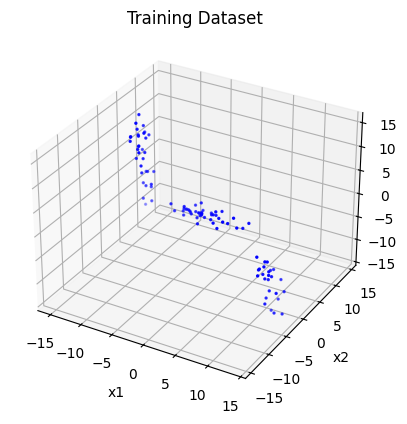

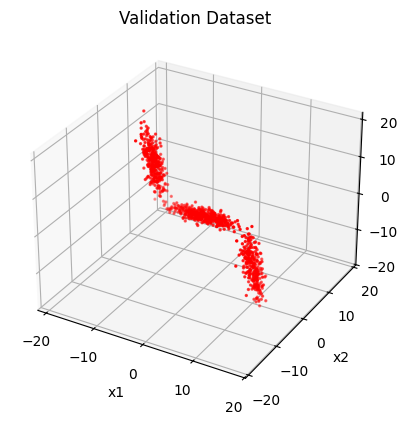

array([ -9.98197182, -10.7759748 ,  -9.04962913,   5.50405363,
        -3.0530714 ,  -1.03870592,  10.19686959,   9.81308193,
        12.44733456,   9.95143796,   9.59808378,  -9.48194996,
       -10.56255463,   1.47888897,  -8.02804956, -10.6522687 ,
         5.28610331,  -0.21709819,  -8.28576752,   0.87421677,
         4.52677071,  -1.52312898,  -8.86643434,  10.43325446,
         9.55013468, -10.54140525,  -9.04409516,  -0.27118862,
         2.19245871,   2.19657929,  -0.74466939,  -9.48351975,
        -9.18815948,   2.72135558, -10.48823273, -11.14208025,
        -8.99057691,  -9.04829264,  -2.21327814,  -9.37370092,
        -4.22931682,  -8.57537147,   0.11445384,   9.23909064,
        -0.87888581,  -9.83193883,  11.71300998,  10.06325208,
        -3.07311616,  11.90592267,  -3.45375702, -10.44853638,
         9.85357945,  10.43101599, -10.33093246, -11.72751793,
        -9.41497576,   9.68709641,   6.15470258,  -9.76718766,
        -2.58033225,  -9.58644168, -10.10289917,  10.47

In [13]:
import numpy as np

def hw2q2():
    Ntrain = 100
    data = generateData(Ntrain)
    plot3(data[0,:], data[1,:], data[2,:], title="Training Dataset", col="b")
    xTrain = data[0:2,:]
    yTrain = data[2,:]
    
    Nvalidate = 1000
    data = generateData(Nvalidate)
    plot3(data[0,:], data[1,:], data[2,:], title="Validation Dataset", col="r")
    xValidate = data[0:2,:]
    yValidate = data[2,:]
    
    return xTrain, yTrain, xValidate, yValidate

def generateData(N):
    gmmParameters = {}
    gmmParameters['priors'] = [.3,.4,.3]  # priors should be a row vector
    gmmParameters['meanVectors'] = np.array([[-10, 0, 10], [0, 0, 0], [10, 0, -10]])
    gmmParameters['covMatrices'] = np.zeros((3, 3, 3))
    gmmParameters['covMatrices'][:,:,0] = np.array([[1, 0, -3], [0, 1, 0], [-3, 0, 15]])
    gmmParameters['covMatrices'][:,:,1] = np.array([[8, 0, 0], [0, .5, 0], [0, 0, .5]])
    gmmParameters['covMatrices'][:,:,2] = np.array([[1, 0, -3], [0, 1, 0], [-3, 0, 15]])
    x, labels = generateDataFromGMM(N, gmmParameters)
    return x

def generateDataFromGMM(N, gmmParameters):
    priors = gmmParameters['priors']  # priors should be a row vector
    meanVectors = gmmParameters['meanVectors']
    covMatrices = gmmParameters['covMatrices']
    n = meanVectors.shape[0]  # Data dimensionality
    C = len(priors)  # Number of components
    x = np.zeros((n, N))
    labels = np.zeros((1, N))
    u = np.random.random((1, N))
    thresholds = np.zeros((1, C+1))
    thresholds[:, 0:C] = np.cumsum(priors)
    thresholds[:, C] = 1
    for l in range(C):
        indl = np.where(u <= float(thresholds[:, l]))
        Nl = len(indl[1])
        labels[indl] = (l + 1)
        u[indl] = 1.1
        x[:, indl[1]] = np.transpose(np.random.multivariate_normal(meanVectors[:, l], covMatrices[:, :, l], Nl))
        
    return x, labels

# The following function is edited to modify the plots in a illustrative way
def plot3(a, b, c, mark="o", col="b", title="Dataset"):
    from matplotlib import pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    
    plt.ion()
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(a, b, c, marker=mark, color=col, s=2)
    
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("y")
    ax.set_title(title)

    # Adjust the limits of the plot to make the axes proportional
    max_range = np.array([a.max()-a.min(), b.max()-b.min(), c.max()-c.min()]).max() / 2.0
    
    mean_x = a.mean()
    mean_y = b.mean()
    mean_z = c.mean()

    ax.set_xlim(mean_x - max_range, mean_x + max_range)
    ax.set_ylim(mean_y - max_range, mean_y + max_range)
    ax.set_zlim(mean_z - max_range, mean_z + max_range)
    
    plt.show()

# Run the function to generate and plot the data
Xtrain, ytrain, Xvalid, yvalid = hw2q2()
Xtrain[0]

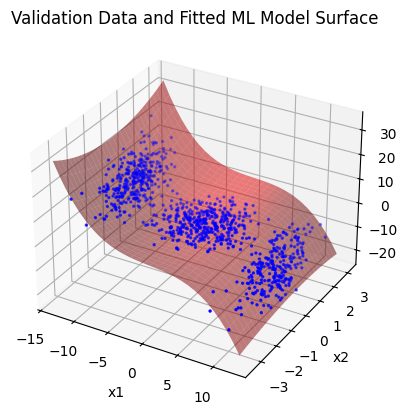

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

# Define a cubic polynomial function c(x, w)
def cubic_polynomial(X, w):
    return w[0] + w[1]*X[0] + w[2]*X[1] + w[3]*X[0]**2 + w[4]*X[1]**2 + w[5]*X[0]*X[1] + w[6]*X[0]**3 + w[7]*X[1]**3 + w[8]*X[0]*X[1]**2 + w[9]*X[1]*X[0]**2

# Objective function for Maximum Likelihood (ML)
def objective_ml(w, X, y):
    y_pred = cubic_polynomial(X, w)
    return np.sum((y - y_pred) ** 2)

# Train ML model
initial_w = np.random.uniform(-1, 1, size=(10, )) # Initial guess for weights
result_ml = minimize(objective_ml, initial_w, args=(Xtrain, ytrain))
w_ml = result_ml.x

# Evaluate ML model on validation set
y_val_pred_ml = np.array([cubic_polynomial(x, w_ml) for x in Xvalid])
ml_error = objective_ml(w_ml, Xvalid, yvalid)

# Plot ML error and MAP errors as a function of gamma
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Xvalid[0, :], Xvalid[1, :], yvalid, c='b', marker='o', label="Validation Data", s=2)

# Now create a surface plot based on the cubic polynomial derived from w_ml
x1_range = np.linspace(Xvalid[0, :].min(), Xvalid[0, :].max(), 30)
x2_range = np.linspace(Xvalid[1, :].min(), Xvalid[1, :].max(), 30)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Compute the predicted y values from the learned w_ml
y_pred_grid = np.array([cubic_polynomial([x1, x2], w_ml) for x1, x2 in zip(np.ravel(x1_grid), np.ravel(x2_grid))])
y_pred_grid = y_pred_grid.reshape(x1_grid.shape)

# Plot the surface of the model's predictions
ax.plot_surface(x1_grid, x2_grid, y_pred_grid, color='r', alpha=0.5, label="Fitted Model Surface")

# Set labels
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.set_title("Validation Data and Fitted ML Model Surface")

# Show the plot with the surface and the data points
plt.show()


MAP Classifier

ML error on validation set: 4.543716741055481
MAP errors for different gamma values: [5.937411993454902, 5.487452079665653, 5.154083893895966, 4.90792548131114, 4.726293196234094, 4.59208827507194, 4.492662214750957, 4.418799517841082, 4.36386425615271, 4.323121882542063, 4.293210624047019, 4.271734538845539, 4.256957196302919, 4.247572935643591, 4.242544805693347, 4.240998819844277, 4.2421656139344055, 4.245358496004464, 4.249973871888934, 4.255502067897347, 4.261538654307742, 4.267788785410815, 4.2740645134439434, 4.280275017068985, 4.286412182321711, 4.292533570624313, 4.298744043496729, 4.305175529903481, 4.311965960846708, 4.319236223282537, 4.327067649401818, 4.335481585489932, 4.34442598759222, 4.353772425697948, 4.363322744273104, 4.372835643928614, 4.382046083160108, 4.39070131117892, 4.398587711267885, 4.405552802984403, 4.411519670865758, 4.416493922600328, 4.42056368458883, 4.423893376153417, 4.426710996234882, 4.429288377849767, 4.4319147489827415, 4.434865030286502, 4.438

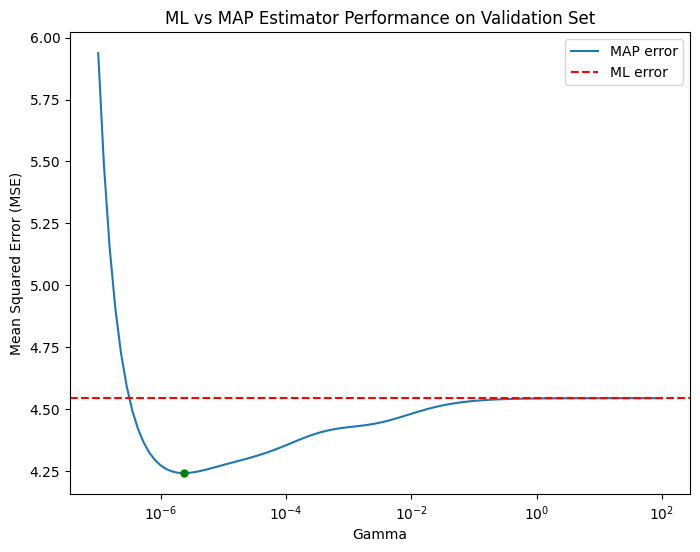

Best gamma with minimum MSE: 2.310129700083158e-06
Minimum MSE on validation set: 4.240998819844277


In [19]:
def cost_map(w, X, y, gamma):
    residuals = y - np.array([cubic_polynomial(X[:, i], w) for i in range(X.shape[1])])
    regularization_term = (1 / gamma) * np.dot(w, w)  # L2 regularization
    return np.sum(residuals**2) + regularization_term


# Range of gamma values for MAP estimation
gammas = np.logspace(-7, 2, 100)  # Range of gamma values from 10^-7 to 10^1
map_errors = []

# Train ML estimator first for comparison (gamma -> infinity means no regularization)
initial_w = np.zeros(10)  # 10 coefficients for the cubic polynomial
result_ml = minimize(lambda w: cost_map(w, Xtrain, ytrain, gamma=np.inf), initial_w)
w_ml = result_ml.x
ml_error = mean_squared_error(yvalid, [cubic_polynomial(x, w_ml) for x in Xvalid.T])

best_gamma = None
min_mse = float('inf')
best_w_map = None

# Train MAP estimators for different values of gamma and compute validation error
for gamma in gammas:
    result_map = minimize(cost_map, initial_w, args=(Xtrain, ytrain, gamma))
    w_map = result_map.x
    y_val_pred_map = np.array([cubic_polynomial(x, w_map) for x in Xvalid.T])
    map_error = mean_squared_error(yvalid, y_val_pred_map)
    map_errors.append(map_error)

    if map_error < min_mse:
        min_mse = map_error
        best_gamma = gamma
        best_w_map = w_map

# Print ML and MAP error for comparison
print(f'ML error on validation set: {ml_error}')
print(f'MAP errors for different gamma values: {map_errors}')

# Plot the errors as a function of gamma
plt.figure(figsize=(8, 6))
plt.plot(gammas, map_errors, '-', label='MAP error')
plt.plot(best_gamma, min_mse, marker='o', markersize=5, markeredgecolor="green", markerfacecolor="green")
plt.axhline(ml_error, color='r', linestyle='--', label='ML error')
plt.xscale('log')
plt.xlabel('Gamma')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('ML vs MAP Estimator Performance on Validation Set')
plt.legend()
plt.show()
print(f'Best gamma with minimum MSE: {best_gamma}')
print(f'Minimum MSE on validation set: {min_mse}')

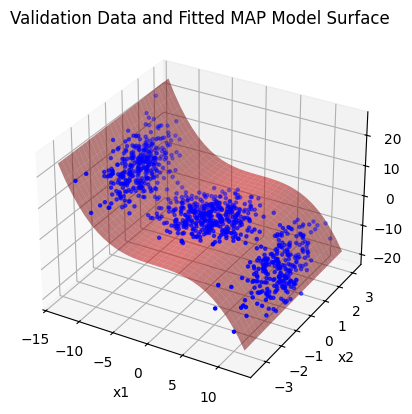

In [24]:
# 3D scatter plot of the validation data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Xvalid[0, :], Xvalid[1, :], yvalid, c='b', marker='o', label="Validation Data", s=5)

# Create a surface plot based on the MAP model with the best gamma
x1_range = np.linspace(Xvalid[0, :].min(), Xvalid[0, :].max(), 30)
x2_range = np.linspace(Xvalid[1, :].min(), Xvalid[1, :].max(), 30)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Compute the predicted y values from the learned w_map for the best gamma
y_pred_grid = np.array([cubic_polynomial([x1, x2], best_w_map) for x1, x2 in zip(np.ravel(x1_grid), np.ravel(x2_grid))])
y_pred_grid = y_pred_grid.reshape(x1_grid.shape)

# Plot the surface of the model's predictions
ax.plot_surface(x1_grid, x2_grid, y_pred_grid, color='r', alpha=0.5, label="Fitted Model Surface (MAP)")

# Set labels and title
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.set_title(f"Validation Data and Fitted MAP Model Surface")

# Show the plot with the surface and the data points
plt.show()

# Question 3

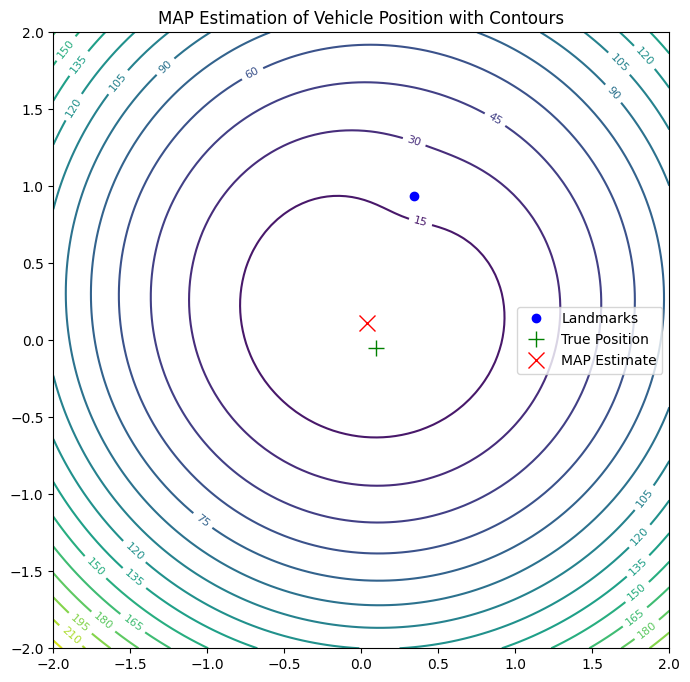

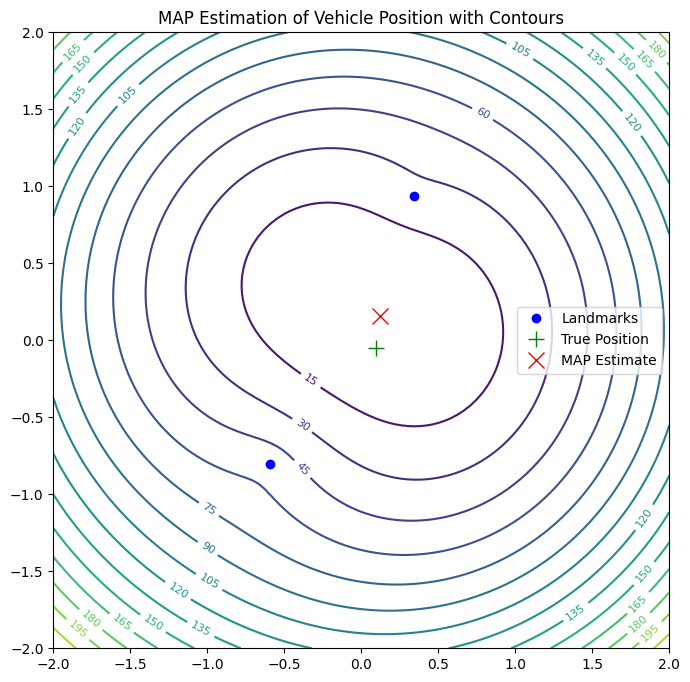

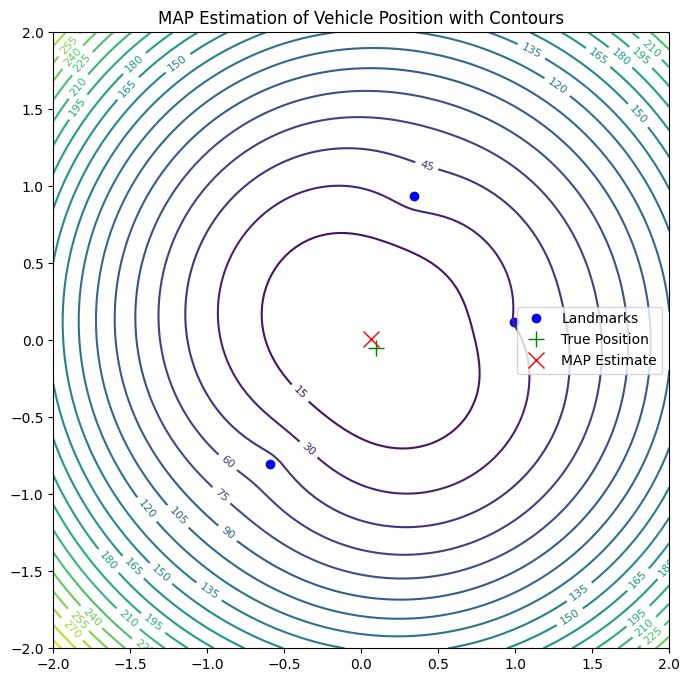

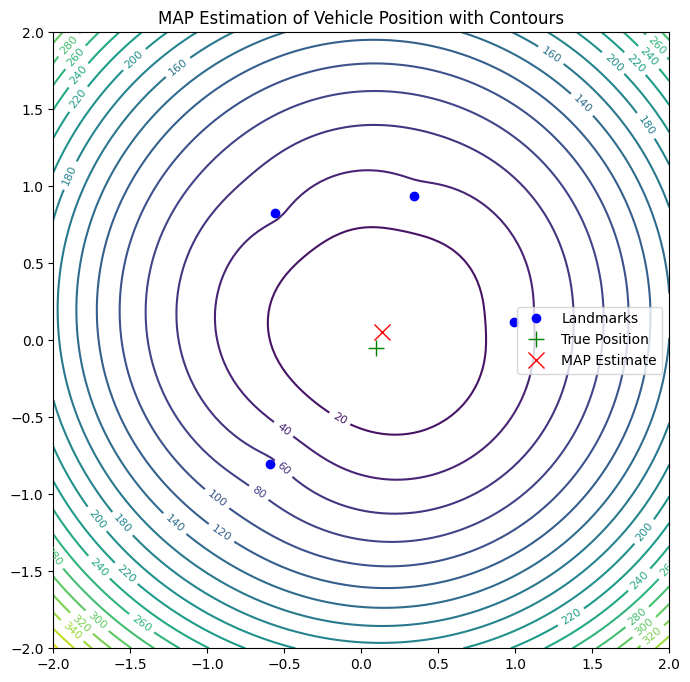

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import random

true_position = np.array([random.uniform(-1, 1), random.uniform(-1, 1)])  # True position of the vehicle generated randomly

def MAP_classifier(angles, sigma_x = 0.25, sigma_y = 0.25, sigma_r = 0.3, position=true_position):

    K = len(angles)
    landmarks = np.array([np.cos(angles), np.sin(angles)]).T

    # Generate range measurements with noise
    def distance(p1, p2):
        return np.sqrt(np.sum((p1 - p2) ** 2))

    true_distances = np.array([distance(position, landmarks[i]) for i in range(K)])
    noise = np.random.normal(0, sigma_r, K)
    range_measurements = true_distances + noise

    # Objective function (MAP estimate)
    def objective(vehicle_position):
        x, y = vehicle_position
        residuals = []
        for i in range(K):
            predicted_distance = np.sqrt((x - landmarks[i, 0]) ** 2 + (y - landmarks[i, 1]) ** 2)
            residuals.append((range_measurements[i] - predicted_distance) ** 2 / sigma_r ** 2)
        prior_term = (x ** 2 / sigma_x ** 2) + (y ** 2 / sigma_y ** 2)
        return np.sum(residuals) + prior_term

    # Minimize the objective function to find the MAP estimate
    initial_guess = np.array([0, 0])  # Start search at origin
    result = minimize(objective, initial_guess)
    map_estimate = result.x

    # Create a grid of points for contour plotting
    x_vals = np.linspace(-2, 2, 100)
    y_vals = np.linspace(-2, 2, 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.array([objective([x, y]) for x, y in zip(X.flatten(), Y.flatten())])
    Z = Z.reshape(X.shape)

    # Plot the landmarks, true position, and MAP estimate
    plt.figure(figsize=(8, 8))
    plt.plot(landmarks[:, 0], landmarks[:, 1], 'bo', label='Landmarks')
    plt.plot(position[0], position[1], 'g+', markersize=12, label='True Position')
    plt.plot(map_estimate[0], map_estimate[1], 'rx', markersize=12, label='MAP Estimate')

    # Contour plot of the objective function
    contour = plt.contour(X, Y, Z, levels=20, cmap='viridis')
    plt.clabel(contour, inline=True, fontsize=8)

    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend()
    plt.title('MAP Estimation of Vehicle Position with Contours')
    plt.show()

angles = [random.uniform(0, 2 * np.pi) for i in range(4)]
for k in range(4):
    angle = angles[:k+1]
    MAP_classifier(angles=angle)